In [ ]:
!pip install PyMuPDF

In [ ]:
# Perform Google Colab installs (if running in Google Colab)
import os

if "COLAB_GPU" in os.environ:
    print("[INFO] Running in Google Colab, installing requirements.")
    !pip install -U torch # requires torch 2.1.1+ (for efficient sdpa implementation)
    !pip install PyMuPDF # for reading PDFs with Python
    !pip install tqdm # for progress bars
    !pip install sentence-transformers # for embedding models
    !pip install accelerate # for quantization model loading
    !pip install bitsandbytes # for quantizing models (less storage space)
    !pip install flash-attn --no-build-isolation # for faster attention mechanism = faster LLM inference

In [ ]:
!pip install -U torch torchvision
from sentence_transformers import SentenceTransformer

In [2]:
# Download PDF file
import os
import requests

# Get PDF document
pdf_path = "/content/drive/MyDrive/doc/T.pdf"

In [ ]:
# Requires !pip install PyMuPDF, see: https://github.com/pymupdf/pymupdf
import fitz # (pymupdf, found this is better than pypdf for our use case, note: licence is AGPL-3.0, keep that in mind if you want to use any code commercially)
from tqdm.auto import tqdm # for progress bars, requires !pip install tqdm

def text_formatter(text: str) -> str:
    """Performs minor formatting on text."""
    cleaned_text = text.replace("\n", " ").strip() # note: this might be different for each doc (best to experiment)

    # Other potential text formatting functions can go here
    return cleaned_text

# Open PDF and get lines/pages
# Note: this only focuses on text, rather than images/figures etc
def open_and_read_pdf(pdf_path: str) -> list[dict]:
    """
    Opens a PDF file, reads its text content page by page, and collects statistics.

    Parameters:
        pdf_path (str): The file path to the PDF document to be opened and read.

    Returns:
        list[dict]: A list of dictionaries, each containing the page number
        (adjusted), character count, word count, sentence count, token count, and the extracted text
        for each page.
    """
    doc = fitz.open(pdf_path)  # open a document
    pages_and_texts = []
    for page_number, page in tqdm(enumerate(doc)):  # iterate the document pages
        text = page.get_text()  # get plain text encoded as UTF-8
        text = text_formatter(text)
        pages_and_texts.append({"page_number": page_number,
                                "page_char_count": len(text),
                                "page_word_count": len(text.split(" ")),
                                "page_sentence_count_raw": len(text.split(". ")),
                                "page_token_count": len(text) / 4,  # 1 token = ~4 chars, see: https://help.openai.com/en/articles/4936856-what-are-tokens-and-how-to-count-them
                                "text": text})
    return pages_and_texts

pages_and_texts = open_and_read_pdf(pdf_path=pdf_path)
pages_and_texts[:2]

In [4]:
import random

random.sample(pages_and_texts, k=3)

[{'page_number': 5,
  'page_char_count': 2568,
  'page_word_count': 430,
  'page_sentence_count_raw': 12,
  'page_token_count': 642.0,
  'text': 'This study aims to explore the following questions:  1. What kinds of factors inform the materiality, construction process and spatial design of housing  in present day Singareni?  2. Who are the major stakeholders and decision-makers (within and outside the households) who  take such decisions?  3. How do different housing (design and construction) arrangements shape people’s experience  of heat in Singareni?    Firstly, the study aims to highlight that the process of constructing a house including the decisions  around materiality, building techniques and design vary across households and are directed by specific  socio-economic factors such as ‘sense of security or agency’, ‘financial capacity’ and ‘access to  knowledge of building construction’. Secondly, it aims to understand how such decisions and choices  create specific kinds of built

In [5]:
import pandas as pd

df = pd.DataFrame(pages_and_texts)
df.head()

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,text
0,0,3263,576,21,815.75,"Gender, Vulnerabilities, Livelihood and Heat ..."
1,1,2728,486,16,682.00,Apart from these heat stress in women who suff...
2,2,2299,390,17,574.75,Figure 1: A makeshift arrangement for paid wor...
3,3,1920,371,12,480.00,"Geeta, a women in her late forties, a victim o..."
4,4,2457,414,16,614.25,Housing construction as a social process: Dive...


In [6]:
# Get stats
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count
count,28.00,28.00,28.00,28.00,28.00
mean,13.50,1989.39,357.54,14.57,497.35
std,8.23,920.81,170.46,7.79,230.20
min,0.00,0.00,1.00,1.00,0.00
25%,6.75,1569.25,274.75,9.75,392.31
50%,13.50,1900.00,346.00,14.00,475.00
75%,20.25,2608.00,462.00,19.25,652.00
max,27.00,3554.00,697.00,34.00,888.50


In [7]:
from spacy.lang.en import English # see https://spacy.io/usage for install instructions


In [8]:
nlp = English()

# Add a sentencizer pipeline, see https://spacy.io/api/sentencizer/
nlp.add_pipe("sentencizer")

# Create a document instance as an example
doc = nlp("This is a sentence. This another sentence.")
assert len(list(doc.sents)) == 2

# Access the sentences of the document
list(doc.sents)

[This is a sentence., This another sentence.]

In [ ]:
for item in tqdm(pages_and_texts):
    item["sentences"] = list(nlp(item["text"]).sents)

    # Make sure all sentences are strings
    item["sentences"] = [str(sentence) for sentence in item["sentences"]]

    # Count the sentences
    item["page_sentence_count_spacy"] = len(item["sentences"])

In [10]:
# Inspect an example
random.sample(pages_and_texts, k=1)

[{'page_number': 18,
  'page_char_count': 2336,
  'page_word_count': 454,
  'page_sentence_count_raw': 23,
  'page_token_count': 584.0,
  'text': '"What does the fieldwork in Singareni tell us about the relationship  between building materials, architecture and vulnerability to heat?"      Building materials in Singareni colony reflect, primarily, the amount of capital that a family is able to  invest in their home. Broadly, there are 5 kinds of materials used, in varying configurations.  Concrete is uncommon, but not unseen. It is mainly used for creating  the walls of homes. Using concrete as roofing is completely unseen,  even in otherwise pucca houses. This is likely due to the significant  increase in cost and complexity that comes along with it. Importantly,  more than one person mentioned that they were not “allowed” to use  concrete for roofing. One person mentioned that it was because the  local leader – Saddam – would not allow it. Another said that it is  because they don’t 

In [11]:
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy
count,28.00,28.00,28.00,28.00,28.00,28.00
mean,13.50,1989.39,357.54,14.57,497.35,15.61
std,8.23,920.81,170.46,7.79,230.20,8.23
min,0.00,0.00,1.00,1.00,0.00,0.00
25%,6.75,1569.25,274.75,9.75,392.31,11.50
50%,13.50,1900.00,346.00,14.00,475.00,15.00
75%,20.25,2608.00,462.00,19.25,652.00,19.25
max,27.00,3554.00,697.00,34.00,888.50,38.00


In [ ]:
# Define split size to turn groups of sentences into chunks
num_sentence_chunk_size = 5

# Create a function that recursively splits a list into desired sizes
def split_list(input_list: list,
               slice_size: int) -> list[list[str]]:
    """
    Splits the input_list into sublists of size slice_size (or as close as possible).

    For example, a list of 17 sentences would be split into two lists of [[10], [7]]
    """
    # If your list has 17 items and size is 5, the range gives you: 0, 5, 10, 15
    return [input_list[i:i + slice_size] for i in range(0, len(input_list), slice_size)]

# Loop through pages and texts and split sentences into chunks
for item in tqdm(pages_and_texts):
    item["sentence_chunks"] = split_list(input_list=item["sentences"],
                                         slice_size=num_sentence_chunk_size)
    item["num_chunks"] = len(item["sentence_chunks"])

In [ ]:
def split_list_new(input_list, slice_size):
    # Create an empty list to hold our chunks
    chunks = []

    # Loop through the list, hopping by 'slice_size' (e.g., 0, 5, 10...)
    for i in range(0, len(input_list), slice_size):

        # Create the chunk
        chunk = input_list[i : i + slice_size]

        # Add it to our list
        chunks.append(chunk)

    return chunks

In [13]:
# Sample an example from the group (note: many samples have only 1 chunk as they have <=10 sentences total)
random.sample(pages_and_texts, k=1)

[{'page_number': 19,
  'page_char_count': 1203,
  'page_word_count': 232,
  'page_sentence_count_raw': 14,
  'page_token_count': 300.75,
  'text': 'Asbestos sheeting and metal sheeting (“patra”) are both commonly  used, both for roofing and for walls. In the case of roofs, they are the  choice for the most pucca of houses. Here, they are inset into the  frame of the walls of the building. [x picture]. It is not always clear  when these sheets are asbestos or metal. In less pucca housing,  sheets may be used as walls, usually in combination with other  kachha materials. These are almost always asbestos, since it is far  stiffer than metal sheets.   In the first image, see painted asbestos being used as walls, besides a  decidedly pucca house made of AAC bricks. This house, too, has a  sheet roof. In the second image,  see the sheeting embedded in the  walls to form the roof.     These materials are  particularly common in  kachha houses, and as  the roofing in semi-pucca  houses. It is 

In [14]:
# Create a DataFrame to get stats
df = pd.DataFrame(pages_and_texts)
df.describe().round(2)

,page_number,page_char_count,page_word_count,page_sentence_count_raw,page_token_count,page_sentence_count_spacy,num_chunks
count,28.00,28.00,28.00,28.00,28.00,28.00,28.00
mean,13.50,1989.39,357.54,14.57,497.35,15.61,3.50
std,8.23,920.81,170.46,7.79,230.20,8.23,1.73
min,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,6.75,1569.25,274.75,9.75,392.31,11.50,2.75
50%,13.50,1900.00,346.00,14.00,475.00,15.00,3.00
75%,20.25,2608.00,462.00,19.25,652.00,19.25,4.00
max,27.00,3554.00,697.00,34.00,888.50,38.00,8.00


In [15]:
print(498/16)

31.125


In [ ]:
import re

# Split each chunk into its own item
pages_and_chunks = []
for item in tqdm(pages_and_texts):
    for sentence_chunk in item["sentence_chunks"]:
        chunk_dict = {}
        chunk_dict["page_number"] = item["page_number"]

        # Join the sentences together into a paragraph-like structure, aka a chunk (so they are a single string)
        joined_sentence_chunk = "".join(sentence_chunk).replace("  ", " ").strip()
        # ['Hello.', 'World'] would actually become "Hello.World" with no space in between.
        joined_sentence_chunk = re.sub(r'\.([A-Z])', r'. \1', joined_sentence_chunk) # ".A" -> ". A" for any full-stop/capital letter combo
        chunk_dict["sentence_chunk"] = joined_sentence_chunk

        # Get stats about the chunk
        chunk_dict["chunk_char_count"] = len(joined_sentence_chunk)
        chunk_dict["chunk_word_count"] = len([word for word in joined_sentence_chunk.split(" ")])
        chunk_dict["chunk_token_count"] = len(joined_sentence_chunk) / 4 # 1 token = ~4 characters

        pages_and_chunks.append(chunk_dict)

# How many chunks do we have?
len(pages_and_chunks)

If the text is "Hello.There":

Match: It finds . followed by T.

Capture: It saves T as Group 1.

Replace: It writes a dot, a space, and then pastes T.

Result: "Hello. There"

Without \1, you wouldn't know which letter to put back! If you just wrote r'. ', the result would be "Hello. here" (the "T" would be deleted). \1 saves the letter from being deleted.

In [17]:
# View a random sample
random.sample(pages_and_chunks, k=1)

[{'page_number': 13,
  'sentence_chunk': "The fan repair is costing me Rs.300. The burning of appliances mostly happens during the summers.” Fieldwork in Singareni also directs us towards another key insight, that indicates that residents perceive legal water and electricity connections, along with meters, as crucial prerequisites for acquiring the allocation of 'Patta' or legal land rights. Accounts of one of our male respondents states his ongoing struggle to obtain legal ownership of their lands through land title deeds or ‘pattas’ for more than a decade.",
  'chunk_char_count': 522,
  'chunk_word_count': 81,
  'chunk_token_count': 130.5}]

In [18]:
# Get stats about our chunks
df = pd.DataFrame(pages_and_chunks)
df.describe().round(2)

,page_number,chunk_char_count,chunk_word_count,chunk_token_count
count,98.00,98.00,98.00,98.00
mean,13.77,558.81,93.28,139.70
std,8.57,226.84,35.70,56.71
min,0.00,8.00,2.00,2.00
25%,6.00,414.50,67.25,103.62
50%,13.50,568.00,94.00,142.00
75%,21.00,716.25,117.00,179.06
max,27.00,1167.00,181.00,291.75


In [19]:
# Show random chunks with under 30 tokens in length
min_token_length = 30
for row in df[df["chunk_token_count"] <= min_token_length].sample(2).iterrows():
    print(f'Chunk token count: {row[1]["chunk_token_count"]} | Text: {row[1]["sentence_chunk"]}')

Chunk token count: 27.75 | Text: 4      Source: Author  A resident put a lock on their tap to prevent people from using the water from her tank.
Chunk token count: 2.0 | Text: He says,


.to_dict(orient="records")
this gives list of dictionaries

In [20]:
pages_and_chunks_over_min_token_len = df[df["chunk_token_count"] > min_token_length].to_dict(orient="records")
pages_and_chunks_over_min_token_len[:2]

[{'page_number': 0,
  'sentence_chunk': 'Gender, Vulnerabilities, Livelihood and Heat  What does the fieldwork in Singarni talk about women, their livelihood, and vulnerabilities, and their relation with heat? Context Gender inequalities and gender roles play a significant role in the way different genders perform or function in a community. Their experiences differ in terms of their needs and preferences which usually varies along space and time. This affects the way in which they experience heat, and on a broader level, climate change. This study however, focuses to analyse ways in which women in Singareni cope with heat within their vulnerabilities and how they shape their daily life to adapt to increasing temperatures.',
  'chunk_char_count': 691,
  'chunk_word_count': 108,
  'chunk_token_count': 172.75},
 {'page_number': 0,
  'sentence_chunk': 'Our fieldwork in Singareni constitute 48 survey participants out of which 29 are women of various age groups, most of whom fall in the age

In [21]:
random.sample(pages_and_chunks_over_min_token_len, k=1)

[{'page_number': 9,
  'sentence_chunk': 'Context Our fieldwork suggests that only a handful of houses in Singareni hold ‘pattas’. These houses stand out prominently from the other informal structures in the neighborhood. The patta- holding houses are pucca, concretely built with defined boundary walls. In contrast, the informal houses are semi-pucca, non-engineered, temporary self-built housing without any defined boundary. These houses tend to extend spatially as occupants seize any opportunity to occupy adjacent plots of land whenever possible.',
  'chunk_char_count': 511,
  'chunk_word_count': 73,
  'chunk_token_count': 127.75}]

Smaller chunks filtered

#embedding

In [1]:
from sentence_transformers import SentenceTransformer

In [ ]:

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device="cuda") # choose the device to load the model to (note: GPU will often be *much* faster than CPU)


In [23]:
single_sentence = "hi my name is mahesh"
single_embedding = embedding_model.encode(single_sentence)
print(f"Sentence: {single_sentence}")
print(f"Embedding:\n{single_embedding}")
print(f"Embedding size: {single_embedding.shape}")

Sentence: hi my name is mahesh
Embedding:
[ 9.00661293e-03 -6.62924768e-03 -2.05694567e-02 -2.44549271e-02
  1.50882890e-02 -3.00638899e-02 -3.51685658e-03  5.08800941e-03
  5.95036801e-03 -1.52491210e-02  3.63118984e-02 -3.55811231e-02
  3.63209657e-02  5.28413765e-02 -6.09619357e-03 -3.82869318e-02
  3.76814902e-02 -3.31642665e-02 -3.40552554e-02 -8.97049252e-03
  1.84241799e-03 -1.45594245e-02 -1.27982069e-02  3.87892947e-02
 -1.21440329e-02  2.30057295e-02  2.82968376e-02  2.60579633e-03
 -1.48749612e-02  1.30438525e-02  2.17808480e-03 -2.22855434e-02
  1.79003272e-02  4.05304730e-02  1.78215794e-06 -4.31341976e-02
 -1.39306365e-02 -5.28637879e-03 -3.08308527e-02 -4.41055596e-02
  4.41689976e-03 -3.05670947e-02  5.59112104e-03  1.84538122e-02
  3.77252954e-03 -4.34432458e-03  3.55971716e-02  2.90452805e-03
  1.02587591e-03  7.33646676e-02 -1.35965887e-02 -4.45355028e-02
  2.01366539e-03 -5.78187257e-02  5.22136763e-02  1.38802221e-02
  3.66475061e-02  6.22994527e-02 -2.70542204e-02

In [ ]:
%%time

# Send the model to the GPU
embedding_model.to("cuda") # requires a GPU installed, for reference on my local machine, I'm using a NVIDIA RTX 4090

# Create embeddings one by one on the GPU
for item in tqdm(pages_and_chunks_over_min_token_len):
    item["embedding"] = embedding_model.encode(item["sentence_chunk"])

In [25]:
# Turn text chunks into a single list
text_chunks = [item["sentence_chunk"] for item in pages_and_chunks_over_min_token_len]

In [ ]:
%%time

# Embed all texts in batches
text_chunk_embeddings = embedding_model.encode(text_chunks,
                                               batch_size=32, # you can use different batch sizes here for speed/performance, I found 32 works well for this use case
                                               convert_to_tensor=True) # optional to return embeddings as tensor instead of array

text_chunk_embeddings

In [27]:
# Save embeddings to file
text_chunks_and_embeddings_df = pd.DataFrame(pages_and_chunks_over_min_token_len)
embeddings_df_save_path = "text_chunks_and_embeddings_df.csv"
text_chunks_and_embeddings_df.to_csv(embeddings_df_save_path, index=False)

In [3]:
import pandas as pd


In [4]:
# Import saved file and view
text_chunks_and_embedding_df_load = pd.read_csv('/content/drive/MyDrive/doc/text_chunks_and_embeddings_df.csv')
text_chunks_and_embedding_df_load.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,0,"Gender, Vulnerabilities, Livelihood and Heat ...",691,108,172.75,[-2.85926554e-02 1.07600316e-02 -2.79739406e-...
1,0,Our fieldwork in Singareni constitute 48 surve...,668,108,167.00,[-1.35175763e-02 8.05033278e-03 -3.02411360e-...
2,0,"Anjali, a teacher at a private school, residin...",599,110,149.75,[-4.25618105e-02 -2.37695668e-02 -1.94483493e-...
3,0,"Sameena, mother of a two-year-old, said that s...",846,138,211.50,[-4.21728529e-02 1.05190184e-02 -2.48128045e-...
4,0,In addition to this frequent power cuts during...,413,70,103.25,[-7.23861530e-02 -3.22346315e-02 -8.46074615e-...


In [6]:
import random

import torch
import numpy as np
import pandas as pd

device = "cuda" if torch.cuda.is_available() else "cpu"

# Import texts and embedding df
text_chunks_and_embedding_df = pd.read_csv('/content/drive/MyDrive/doc/text_chunks_and_embeddings_df.csv')

# Convert embedding column back to np.array (it got converted to string when it got saved to CSV)
text_chunks_and_embedding_df["embedding"] = text_chunks_and_embedding_df["embedding"].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert texts and embedding df to list of dicts
pages_and_chunks = text_chunks_and_embedding_df.to_dict(orient="records")

# Convert embeddings to torch tensor and send to device (note: NumPy arrays are float64, torch tensors are float32 by default)
embeddings = torch.tensor(np.array(text_chunks_and_embedding_df["embedding"].tolist()), dtype=torch.float32).to(device)
embeddings.shape

torch.Size([96, 768])

In [7]:
text_chunks_and_embedding_df.head()

,page_number,sentence_chunk,chunk_char_count,chunk_word_count,chunk_token_count,embedding
0,0,"Gender, Vulnerabilities, Livelihood and Heat ...",691,108,172.75,"[-0.0285926554, 0.0107600316, -0.0279739406, -..."
1,0,Our fieldwork in Singareni constitute 48 surve...,668,108,167.00,"[-0.0135175763, 0.00805033278, -0.0030241136, ..."
2,0,"Anjali, a teacher at a private school, residin...",599,110,149.75,"[-0.0425618105, -0.0237695668, -0.0194483493, ..."
3,0,"Sameena, mother of a two-year-old, said that s...",846,138,211.50,"[-0.0421728529, 0.0105190184, -0.0248128045, -..."
4,0,In addition to this frequent power cuts during...,413,70,103.25,"[-0.072386153, -0.0322346315, -0.00846074615, ..."


In [8]:
embeddings[0]

tensor([-2.8593e-02,  1.0760e-02, -2.7974e-02, -6.1234e-03,  3.1537e-02,
         5.2124e-02,  5.5901e-02, -2.8784e-02,  8.0694e-02, -1.0867e-02,
         4.0762e-02,  5.5115e-02,  6.2382e-02, -5.5818e-02,  3.8567e-02,
        -5.7858e-02, -1.8229e-03, -4.3074e-03, -7.0933e-03,  3.4833e-02,
        -2.1144e-02,  2.7835e-02,  9.9573e-03,  7.2524e-03,  1.3703e-02,
        -5.7377e-02,  9.9960e-03,  1.5233e-02,  4.1677e-02, -1.6113e-02,
         5.6458e-02, -4.8531e-03,  1.1814e-02, -5.8096e-02,  1.8680e-06,
        -1.8788e-02,  9.2258e-04,  7.4611e-03, -2.1613e-04,  3.9278e-04,
         3.3609e-02, -7.9389e-02, -1.9043e-02,  2.6156e-02, -1.8964e-03,
        -2.2095e-02,  5.3139e-02,  2.2205e-02, -1.8525e-02, -4.9516e-03,
        -1.6698e-03,  1.5285e-02, -5.1169e-02,  1.2932e-02, -1.6913e-02,
         3.8422e-02,  2.8151e-02, -5.2384e-02,  1.5605e-02, -1.6810e-02,
        -3.1729e-02,  3.8249e-02, -3.6117e-02,  8.6312e-03, -5.2000e-02,
         1.9691e-02, -2.2580e-02, -7.9910e-02,  6.0

In [ ]:
from sentence_transformers import util, SentenceTransformer

embedding_model = SentenceTransformer(model_name_or_path="all-mpnet-base-v2",
                                      device=device) # choose the device to load the model to

In [10]:
# 1. Define the query
# Note: This could be anything. But since we're working with a nutrition textbook, we'll stick with nutrition-based queries.
query = "Feeble Water Infrastructures and Thermal Comfort in Singareni"
print(f"Query: {query}")

# 2. Embed the query to the same numerical space as the text examples
# Note: It's important to embed your query with the same model you embedded your examples with.
query_embedding = embedding_model.encode(query, convert_to_tensor=True)

# 3. Get similarity scores with the dot product (we'll time this for fun)
from time import perf_counter as timer

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

# 4. Get the top-k results (we'll keep this to 5)
top_results_dot_product = torch.topk(dot_scores, k=5)
top_results_dot_product

Query: Feeble Water Infrastructures and Thermal Comfort in Singareni
Time take to get scores on 96 embeddings: 0.00081 seconds.


torch.return_types.topk(
values=tensor([0.8648, 0.7501, 0.7361, 0.6935, 0.6851]),
indices=tensor([76, 93, 83, 95, 30]))

In [11]:
larger_embeddings = torch.randn(100*embeddings.shape[0], 768).to(device)
print(f"Embeddings shape: {larger_embeddings.shape}")

start_time = timer()
dot_scores = util.dot_score(a=query_embedding, b=larger_embeddings)[0]
end_time = timer()

print(f"Time take to get scores on {len(larger_embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

Embeddings shape: torch.Size([9600, 768])
Time take to get scores on 9600 embeddings: 0.00688 seconds.


In [12]:
# Define helper function to print wrapped text
import textwrap

def print_wrapped(text, wrap_length=80):
    wrapped_text = textwrap.fill(text, wrap_length)
    print(wrapped_text)

In [13]:
print(f"Query: '{query}'\n")
print("Results:")
# Loop through zipped together scores and indicies from torch.topk
for score, idx in zip(top_results_dot_product[0], top_results_dot_product[1]):
    print(f"Score: {score:.4f}")
    # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
    print("Text:")
    print_wrapped(pages_and_chunks[idx]["sentence_chunk"])
    # Print the page number too so we can reference the textbook further (and check the results)
    print(f"Page number: {pages_and_chunks[idx]['page_number']}")
    print("\n")

Query: 'Feeble Water Infrastructures and Thermal Comfort in Singareni'

Results:
Score: 0.8648
Text:
1      Feeble Water Infrastructures and Thermal Comfort in Singareni    One way
to understand Singareni colony’s water politics and vulnerability to heat is
through understanding the water histories in the area. During my fieldwork in
Singareni colony, I could not help but wonder: how is one supposed to take
measures against heat when they do not have proper infrastructure for water and
electricity?A simple, seemingly obvious question felt so important to ask and
answer. In the often-had conversation of ever-increasing emissions due to
increasing air conditioning, where does a place that does not have water and
electricity connections fall?Here, there is no space to lament about the paradox
of air conditioning.
Page number: 24


Score: 0.7501
Text:
The Water Board decided to want none of these headaches. They removed the
municipal taps… We were also able to raise demands for tanker supp

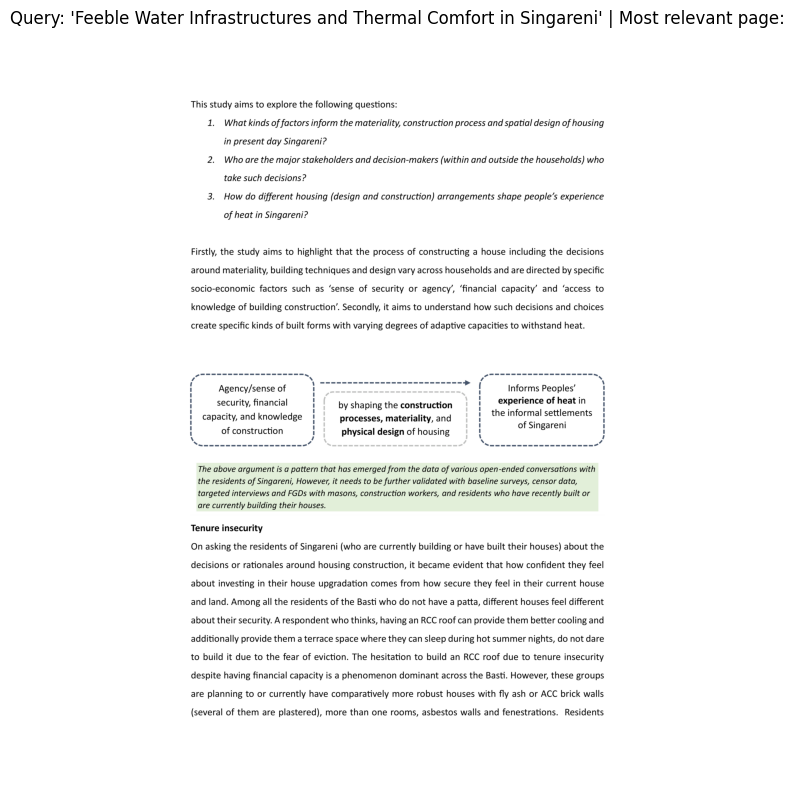

In [16]:
import fitz

# Open PDF and load target page
pdf_path = "/content/drive/MyDrive/doc/Thesis.pdf" # requires PDF to be downloaded
doc = fitz.open(pdf_path)
page = doc.load_page(5) # number of page

# Get the image of the page
img = page.get_pixmap(dpi=300)

# Optional: save the image
#img.save("output_filename.png")
doc.close()

# Convert the Pixmap to a numpy array
img_array = np.frombuffer(img.samples_mv,
                          dtype=np.uint8).reshape((img.h, img.w, img.n))

# Display the image using Matplotlib
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 10))
plt.imshow(img_array)
plt.title(f"Query: '{query}' | Most relevant page:")
plt.axis('off') # Turn off axis
plt.show()

In [17]:
import torch

def dot_product(vector1, vector2):
    return torch.dot(vector1, vector2)

def cosine_similarity(vector1, vector2):
    dot_product = torch.dot(vector1, vector2)

    # Get Euclidean/L2 norm of each vector (removes the magnitude, keeps direction)
    norm_vector1 = torch.sqrt(torch.sum(vector1**2))
    norm_vector2 = torch.sqrt(torch.sum(vector2**2))

    return dot_product / (norm_vector1 * norm_vector2)

# Example tensors
vector1 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector2 = torch.tensor([1, 2, 3], dtype=torch.float32)
vector3 = torch.tensor([4, 5, 6], dtype=torch.float32)
vector4 = torch.tensor([-1, -2, -3], dtype=torch.float32)

# Calculate dot product
print("Dot product between vector1 and vector2:", dot_product(vector1, vector2))
print("Dot product between vector1 and vector3:", dot_product(vector1, vector3))
print("Dot product between vector1 and vector4:", dot_product(vector1, vector4))

# Calculate cosine similarity
print("Cosine similarity between vector1 and vector2:", cosine_similarity(vector1, vector2))
print("Cosine similarity between vector1 and vector3:", cosine_similarity(vector1, vector3))
print("Cosine similarity between vector1 and vector4:", cosine_similarity(vector1, vector4))

Dot product between vector1 and vector2: tensor(14.)
Dot product between vector1 and vector3: tensor(32.)
Dot product between vector1 and vector4: tensor(-14.)
Cosine similarity between vector1 and vector2: tensor(1.0000)
Cosine similarity between vector1 and vector3: tensor(0.9746)
Cosine similarity between vector1 and vector4: tensor(-1.0000)


In [18]:
def retrieve_relevant_resources(query: str,
                                embeddings: torch.tensor,
                                model: SentenceTransformer=embedding_model,
                                n_resources_to_return: int=5,
                                print_time: bool=True):
    """
    Embeds a query with model and returns top k scores and indices from embeddings.
    """

    # Embed the query
    query_embedding = model.encode(query,
                                   convert_to_tensor=True)

    # Get dot product scores on embeddings
    start_time = timer()
    dot_scores = util.dot_score(query_embedding, embeddings)[0]
    end_time = timer()

    if print_time:
        print(f"[INFO] Time taken to get scores on {len(embeddings)} embeddings: {end_time-start_time:.5f} seconds.")

    scores, indices = torch.topk(input=dot_scores,
                                 k=n_resources_to_return)

    return scores, indices

def print_top_results_and_scores(query: str,
                                 embeddings: torch.tensor,
                                 pages_and_chunks: list[dict]=pages_and_chunks,
                                 n_resources_to_return: int=5):
    """
    Takes a query, retrieves most relevant resources and prints them out in descending order.

    Note: Requires pages_and_chunks to be formatted in a specific way (see above for reference).
    """

    scores, indices = retrieve_relevant_resources(query=query,
                                                  embeddings=embeddings,
                                                  n_resources_to_return=n_resources_to_return)

    print(f"Query: {query}\n")
    print("Results:")
    # Loop through zipped together scores and indicies
    for score, index in zip(scores, indices):
        print(f"Score: {score:.4f}")
        # Print relevant sentence chunk (since the scores are in descending order, the most relevant chunk will be first)
        print_wrapped(pages_and_chunks[index]["sentence_chunk"])
        # Print the page number too so we can reference the textbook further and check the results
        print(f"Page number: {pages_and_chunks[index]['page_number']}")
        print("\n")

Excellent! Now let's test our functions out.

In [19]:
query = "Feeble Water Infrastructures and Thermal Comfort in Singareni "

# Get just the scores and indices of top related results
scores, indices = retrieve_relevant_resources(query=query,
                                              embeddings=embeddings)
scores, indices

[INFO] Time taken to get scores on 96 embeddings: 0.01086 seconds.


(tensor([0.8648, 0.7501, 0.7361, 0.6935, 0.6851]),
 tensor([76, 93, 83, 95, 30]))

In [20]:
# Print out the texts of the top scores
print_top_results_and_scores(query=query,
                             embeddings=embeddings)

[INFO] Time taken to get scores on 96 embeddings: 0.00025 seconds.
Query: Feeble Water Infrastructures and Thermal Comfort in Singareni 

Results:
Score: 0.8648
1      Feeble Water Infrastructures and Thermal Comfort in Singareni    One way
to understand Singareni colony’s water politics and vulnerability to heat is
through understanding the water histories in the area. During my fieldwork in
Singareni colony, I could not help but wonder: how is one supposed to take
measures against heat when they do not have proper infrastructure for water and
electricity?A simple, seemingly obvious question felt so important to ask and
answer. In the often-had conversation of ever-increasing emissions due to
increasing air conditioning, where does a place that does not have water and
electricity connections fall?Here, there is no space to lament about the paradox
of air conditioning.
Page number: 24


Score: 0.7501
The Water Board decided to want none of these headaches. They removed the
municipal ta